In [2]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
import sys

sys.path.append(str(Path.cwd().parent/ "src"))

from ecg_scanner.scanner import ECGScanner

p = Path.cwd().parent / "datasets" / "images"



In [24]:
def enhance(im):
    # Mild color correction 
    gamma = 1.0
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255
                    for i in np.arange(0, 256)]).astype("uint8")
    corrected = cv2.LUT(im, table)
    plt.imshow(corrected)

    # LAB Color Space
    lab = cv2.cvtColor(corrected, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    
    # Gentle CLAHE 
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(12, 12))
    l = clahe.apply(l)
    
    # Merge channels 
    lab = cv2.merge([l, a, b])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

    # Smart saturation boost
    hsv = cv2.cvtColor(enhanced, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    
    # Saturation mask 
    s_clean = cv2.bilateralFilter(s, 9, 75, 75)
    s = cv2.addWeighted(s, 1.2, s_clean, 0.3, 0)
    s = np.clip(s, 20, 230).astype(np.uint8)
    
    hsv = cv2.merge([h, s, v])
    enhanced = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    # Controlled sharpening
    blurred = cv2.GaussianBlur(enhanced, (0, 0), 2.0)
    sharpened = cv2.addWeighted(enhanced, 1.5, blurred, -0.5, 0)

    # Noise reduction 
    final = cv2.bilateralFilter(sharpened, 9, 75, 75)
    return final

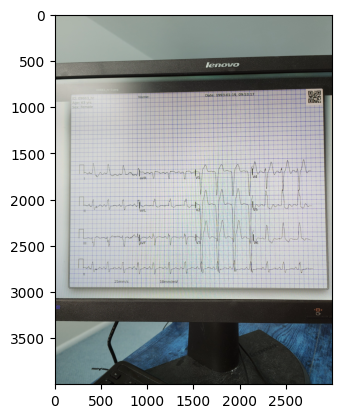

In [25]:
im_path = p / "1124135100-0006.png"
im = cv2.imread(im_path)
img = enhance(im)

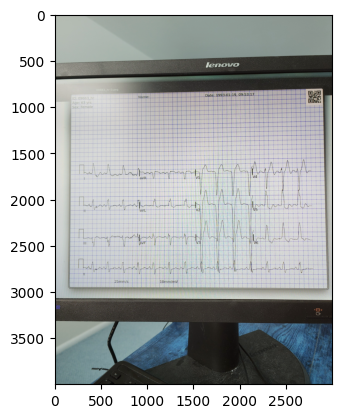

In [10]:
cv2.imwrite(p / "enhanced.png", img)

True

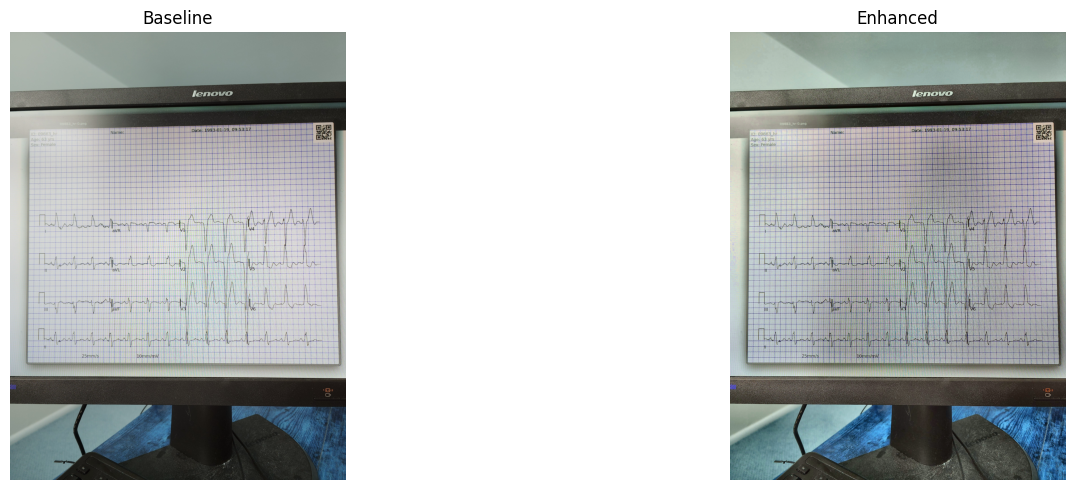

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
ax1.imshow(im, cmap="gray")
ax1.set_title("Baseline")
ax1.axis("off")
ax2.imshow(img, cmap="gray")
ax2.set_title("Enhanced")
ax2.axis("off")
plt.tight_layout()
plt.show()